# Myth #1: Weight gradients explode or vanish without proper initialization 

In [1]:
from functools import partial
import math

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

First, we load the MNIST dataset.

In [2]:
train_ds = MNIST('data', train=True, transform=ToTensor(), download=True)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

Second, we create a 5-layer ReLU MLP and write a custom initialization function.

In [3]:
num_layers = 5

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential()
        for i in range(num_layers-1):
            self.layers.add_module(f"Dense {i+1}", nn.LazyLinear(64))
            self.layers.add_module(f"Activation {i+1}", nn.ReLU())
        self.layers.add_module(f"Dense {num_layers})", nn.LazyLinear(10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)

In [5]:
def custom_init(gain, m):
    if isinstance(m, nn.Linear):
        std = gain * math.sqrt(2 / m.weight.shape[1]) # He init
        nn.init.normal_(m.weight, std=std)
        nn.init.zeros_(m.bias)

def apply_init(model, gain=1.0):
    torch.manual_seed(421314534)
    model(torch.zeros(1, 784)) # initialize lazy layers
    init_fn = partial(custom_init, gain)
    model.apply(init_fn)

Third, we initialize five such MLPs using different values of the `gain` parameter. We then compute and plot, for each MLP, (a) the standard deviation of the gradient of the loss with respect to the weights in each layer, and (b) the standard deviation of the gradient of the loss with respect to the bias in each layer. 

In [6]:
gains = [10**i for i in range(2, -3, -1)]
print(f"Initialization gain factors: {gains}")

Initialization gain factors: [100, 10, 1, 0.1, 0.01]


In [7]:
def compute_gradient_stds(gains, train_dl):
    X, y = next(iter(train_dl))
    weight_grad_stds = [[] for _ in range(len(gains))]
    bias_grad_stds = [[] for _ in range(len(gains))]
    for i, gain in enumerate(gains):
        model = MLP()
        apply_init(model, gain=gain)
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        for m in model.layers:
            if isinstance(m, nn.Linear):
                weight_grad_stds[i].append(torch.std(m.weight.grad).item())
                bias_grad_stds[i].append(torch.std(m.bias.grad).item())
    return weight_grad_stds, bias_grad_stds

In [ ]:
def plot_grad_stds(stds, name, frameon=True):
    plt.figure(figsize=(8, 4.5))
    x = torch.arange(num_layers) + 1
    for i, std in enumerate(stds):
        plt.plot(x, std, marker='o',
             linestyle='-', label=gains[i])
    plt.yscale('log')
    plt.title(f"ReLU MLP", fontsize=16)
    plt.xlabel("Layer number", fontsize=14)
    plt.ylabel(f"Standard deviation of {name} gradient", 
               fontsize=14)
    plt.gca().set_xticks(list(range(1,num_layers+1)))
    plt.gca().set_xticklabels(list(range(1,num_layers+1)), fontsize=12)
    plt.gca().tick_params(axis='x', which='both', length=0)
    plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
    plt.legend(title="Gain", fontsize=12, loc='upper right', 
               bbox_to_anchor=(1,1.1), frameon=frameon)
    plt.tight_layout()
    plt.savefig(f"myth_1_{name}_gradients.png")
    plt.show()

In [9]:
weight_grad_stds, bias_grad_stds = compute_gradient_stds(gains, train_dl)

As we can see, the norm of the weight gradients in a ReLU MLP is constant across the network.

If we were training a weight-only neural network, we could choose the learning rate carefully such that the magnitude of the updates to the weight matrices $\frac{||\Delta W||}{||W||}$ doesn't depend on the `gain` factor.

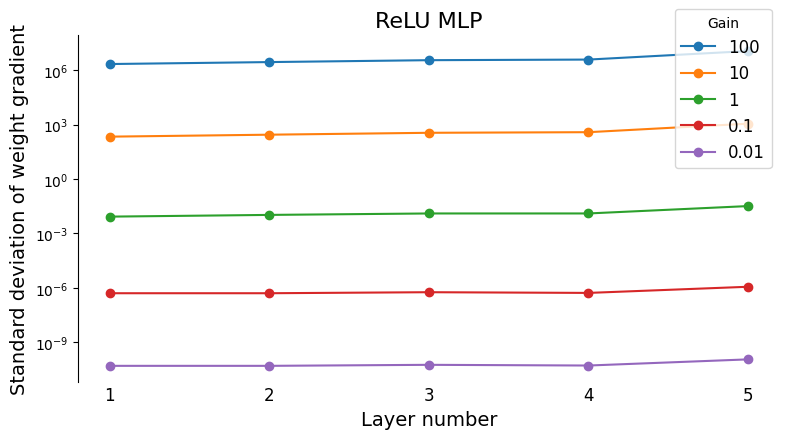

In [10]:
plot_grad_stds(weight_grad_stds, name="weight", frameon=True)


However, the norm of the bias vector gradients is not constant across the network. This means that with a constant per-parameter learning rate (i.e., SGD), the magnitude (i.e., norm) of updates to the bias vectors will vary by orders of magnitude across the network. 

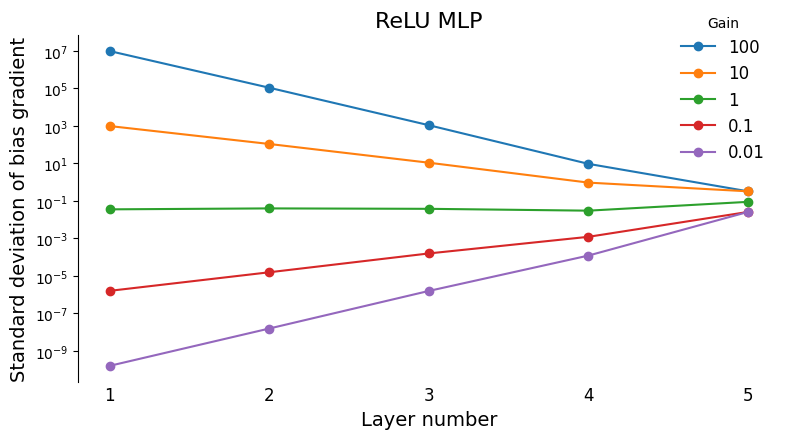

In [11]:
plot_grad_stds(bias_grad_stds, name="bias", frameon=False)

Unfortunately, this means that we cannot choose the learning rate carefully to ensure that the magnitude of the updates to the bias matrix $\frac{||\Delta b||}{||b||}$ doesn't depend on `gain`.

This is one reason that we need to initialize the weights in a ReLU MLP to the correct scale: if the scale of the initialization is not correct, the bias gradient will explode or vanish. 